In [2]:
import requests

url = "http://10.16.65.8/tnav_cgi1/tnav_license_server.cgi"
response = requests.get(url)

if response.status_code == 200:
    with open("tnav_license_server.cgi", "wb") as file:
        file.write(response.content)
    print("Файл скачан успешно.")
else:
    print(f"Ошибка: {response.status_code}")


ConnectTimeout: HTTPConnectionPool(host='10.16.65.8', port=80): Max retries exceeded with url: /tnav_cgi1/tnav_license_server.cgi (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x00000173B40384D0>, 'Connection to 10.16.65.8 timed out. (connect timeout=None)'))

In [6]:
import csv
from bs4 import BeautifulSoup

def parse_articles_from_html(html):
    soup = BeautifulSoup(html, 'html.parser')
    articles = []
    # Находим таблицу с результатами поиска по id "restab"
    table = soup.find('table', id='restab')
    if table:
        # Каждая строка, представляющая публикацию, имеет атрибут id (например, id="a17391090")
        rows = table.find_all('tr', id=True)
        for row in rows:
            # Вторая ячейка содержит информацию о публикации: заголовок и ссылку
            tds = row.find_all('td')
            if len(tds) >= 2:
                link_tag = tds[1].find('a', href=True)
                if link_tag:
                    title = link_tag.get_text(strip=True)
                    href = link_tag['href']
                    # Если ссылка относительная, приводим её к абсолютному виду
                    if href.startswith('/'):
                        href = 'http://www.elibrary.ru' + href
                    articles.append({'title': title, 'link': href})
    return articles

if __name__ == '__main__':
    # Допустим, HTML-страницу сохранили в файл "elibrary.html"
    with open('elibrary.html', encoding='utf-8') as f:
        html = f.read()
    
    articles = parse_articles_from_html(html)
    
    # Выводим найденные статьи в консоль
    for article in articles:
        print(f"Название: {article['title']}\nСсылка: {article['link']}\n")
    
    # Сохраняем данные в CSV-файл
    with open('articles.csv', 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['title', 'link']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for article in articles:
            writer.writerow(article)
    
    print(f"Найдено {len(articles)} статей. Данные сохранены в файл articles.csv")


Название: СТАТИСТИКА
Ссылка: https://elibrary.ru/item.asp?id=17391090

Название: ДИФФЕРЕНЦИАЦИЯ НДПИ: ГРУППЫ ФАКТОРОВ
Ссылка: https://elibrary.ru/item.asp?id=17391091

Название: СОВЕРШЕНСТВОВАНИЕ ОРГАНИЗАЦИИ ТЕКУЩЕГО И КАПИТАЛЬНОГО РЕМОНТА СКВАЖИН В НГДУ "ЯМАШНЕФТЬ"
Ссылка: https://elibrary.ru/item.asp?id=17391092

Название: ТЕХНОЛОГИЯ ОТКЛЮЧЕНИЯ ВЕРХНИХ ОБЪЕКТОВ РАЗРАБОТКИ ИСПОЛЬЗОВАНИЕМ МЕТАЛЛИЧЕСКОГО ПЛАСТЫРЯ В КАЧЕСТВЕ ЗАКОЛОННОГО ПАКЕРНОГО УСТРОЙСТВА
Ссылка: https://elibrary.ru/item.asp?id=17391094

Название: ОБ ЭФФЕКТИВНОЙ РАБОТЕ ШАРОШЕЧНОГО ДОЛОТА
Ссылка: https://elibrary.ru/item.asp?id=17391095

Название: ВОССТАНОВЛЕНИЕ СКВАЖИН МЕТОДОМ БУРЕНИЯ БОКОВОГО СТВОЛА
Ссылка: https://elibrary.ru/item.asp?id=17391096

Название: ИЗВЛЕЧЕНИЕ ТРУДНОИЗВЛЕКАЕМЫХ ЗАПАСОВ НЕФТИ ПУТЕМ ОРГАНИЗАЦИИ ОДНОВРЕМЕННО РАЗДЕЛЬНОЙ ЗАКАЧКИ НА КОНИТЛОРСКОМ МЕСТОРОЖДЕНИИ
Ссылка: https://elibrary.ru/item.asp?id=17391097

Название: СПОСОБЫ ЛИКВИДАЦИИ КАТАСТРОФИЧЕСКИХ ПОГЛОЩЕНИЙ ПРИ СТРОИТЕЛЬСТВЕ СКВАЖИН ТИКСОТРО

In [19]:
import time
import re
import csv
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def search_elibrary(query):
    """
    1) Открывает elibrary.ru
    2) Вводит поисковый запрос в поле name='ftext'
    3) Нажимает Enter, чтобы отправить форму
    4) Дожидается появления таблицы с результатами (id='restab')
    5) Возвращает HTML итоговой страницы
    """

    chrome_options = Options()
    # Если не нужен видимый браузер, можно раскомментировать:
    # chrome_options.add_argument("--headless")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    try:
        # Открываем главную страницу
        driver.get("https://elibrary.ru")

        # Находим поле ввода поиска по имени 'ftext'
        search_input = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.NAME, "ftext"))
        )
        # Вводим запрос
        search_input.send_keys(query)
        # Нажимаем Enter, чтобы отправить форму
        search_input.send_keys(Keys.ENTER)

        # Ждем до 20 секунд появления таблицы с id="restab"
        WebDriverWait(driver, 20).until(
            EC.presence_of_element_located((By.ID, "restab"))
        )

        time.sleep(2)  # подстраховка

        # Сохраняем итоговый HTML
        page_html = driver.page_source

    finally:
        driver.quit()

    return page_html

def parse_search_results(html):
    """
    Извлекаем название статьи, авторов, год публикации и ссылку из HTML
    """
    soup = BeautifulSoup(html, "html.parser")
    articles = []

    table = soup.find("table", id="restab")
    if not table:
        print("Таблица с результатами не найдена.")
        return articles

    rows = table.find_all("tr", id=True)
    for row in rows:
        tds = row.find_all("td")
        if len(tds) < 2:
            continue
        # Вторая ячейка содержит данные
        cell = tds[1]

        # Название
        link_tag = cell.find("a", href=True)
        if not link_tag:
            continue
        title = link_tag.get_text(strip=True)

        # Ссылка
        link = link_tag["href"]
        if link.startswith("/"):
            link = "https://elibrary.ru" + link

        # Авторы (обычно в теге <i>)
        authors_tag = cell.find("i")
        authors = authors_tag.get_text(strip=True) if authors_tag else ""

        # Год (ищем 4 цифры, начинающиеся на 19 или 20)
        text_block = cell.get_text(" ", strip=True)
        year_match = re.search(r"\b(19|20)\d{2}\b", text_block)
        year = year_match.group(0) if year_match else ""

        articles.append({
            "title": title,
            "authors": authors,
            "year": year,
            "link": link
        })

    return articles

if __name__ == "__main__":
    query = "разработка месторождений"
    print(f"Ищем: {query}")

    # Получаем HTML
    html = search_elibrary(query)

    # Парсим
    articles_data = parse_search_results(html)
    print(f"Найдено статей: {len(articles_data)}")
    for art in articles_data[:5]:  # выводим первые 5
        print(f"Название: {art['title']}")
        print(f"Авторы: {art['authors']}")
        print(f"Год: {art['year']}")
        print(f"Ссылка: {art['link']}")
        print("-----")

    # Сохраняем в CSV
    with open("articles.csv", "w", newline="", encoding="utf-8") as f:
        fieldnames = ["title","authors","year","link"]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for art in articles_data:
            writer.writerow(art)

    print("Данные сохранены в 'articles.csv'")


Ищем: разработка месторождений
Найдено статей: 100
Название: ВЫБОР ОПТИМАЛЬНОЙ СИСТЕМЫ РАЗРАБОТКИ ПО ОПЫТУ РАЗРАБОТКИ МЕСТОРОЖДЕНИЙ-АНАЛОГОВ НА ПРИМЕРЕ ПОЛЯРНОГО МЕСТОРОЖДЕНИЯ
Авторы: Даценко Е.Н., Орлова И.О., Авакимян Н.Н.
Год: 2020
Ссылка: https://elibrary.ru/item.asp?id=43810388
-----
Название: РАЗРАБОТКА СПОСОБОВ УВЕЛИЧЕНИЯ НЕФТЕОТДАЧИ МЕСТОРОЖДЕНИЙ МАЛОПРОНИЦАЕМЫХ И ТРЕЩИННЫХ ПЛАСТОВ
Авторы: Мамедова М.А.
Год: 2018
Ссылка: https://elibrary.ru/item.asp?id=35033775
-----
Название: СПРАВОЧНИК ПО ОХРАНЕ НЕДР. ПРАВИЛА ОХРАНЫ СООРУЖЕНИЙ И ПРИРОДНЫХ ОБЪЕКТОВ ОТ ВРЕДНОГО ВЛИЯНИЯ ПОДЗЕМНЫХ ГОРНЫХ РАЗРАБОТОК НА УГОЛЬНЫХ МЕСТОРОЖДЕНИЯХ
Авторы: 
Год: 2011
Ссылка: https://elibrary.ru/item.asp?id=19602784
-----
Название: DEVELOPMENT OF INFORMATION RESOURSE FOR MINERAL WATER DEPOSITS KMV
Авторы: Martirosyan K.V., Martirosyan A.V., Makarova A.A., Zyuzin A.S.
Год: 2020
Ссылка: https://elibrary.ru/item.asp?id=44715762
-----
Название: БОЛЬШОЙ СПРАВОЧНИК ИНЖЕНЕРА НЕФТЕГАЗОДОБЫЧИ. РАЗРАБОТКА МЕСТОРОЖ

In [22]:
import time
import re
import csv
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def open_elibrary_and_search(query, headless=False):
    """
    Открывает elibrary.ru, вводит поисковый запрос,
    нажимает Enter для поиска и дожидается первой страницы результатов.
    Возвращает объект WebDriver, уже стоящий на странице результатов #1.
    """

    chrome_options = Options()
    chrome_options.add_argument("--headless")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    driver.get("https://elibrary.ru")

    # Ожидаем поле ввода с name='ftext'
    search_input = WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.NAME, "ftext"))
    )
    search_input.send_keys(query)
    search_input.send_keys(Keys.ENTER)

    # Ожидаем появления таблицы с id="restab" (первая страница результатов)
    WebDriverWait(driver, 20).until(
        EC.presence_of_element_located((By.ID, "restab"))
    )

    time.sleep(1)  # небольшая задержка
    return driver

def parse_current_page(driver):
    """
    Извлекает данные о статьях с текущей страницы, возвращает список словарей.
    Каждая статья: title, authors, year, link
    """
    soup = BeautifulSoup(driver.page_source, "html.parser")
    table = soup.find("table", id="restab")
    articles = []
    if not table:
        return articles

    rows = table.find_all("tr", id=True)
    for row in rows:
        tds = row.find_all("td")
        if len(tds) < 2:
            continue
        cell = tds[1]

        # Название и ссылка
        link_tag = cell.find("a", href=True)
        if not link_tag:
            continue
        title = link_tag.get_text(strip=True)
        link = link_tag["href"]
        if link.startswith("/"):
            link = "https://elibrary.ru" + link

        # Авторы
        authors_tag = cell.find("i")
        authors = authors_tag.get_text(strip=True) if authors_tag else ""

        # Год (первая 4-значная встреча)
        text_block = cell.get_text(" ", strip=True)
        year_match = re.search(r"\b(19|20)\d{2}\b", text_block)
        year = year_match.group(0) if year_match else ""

        articles.append({
            "title": title,
            "authors": authors,
            "year": year,
            "link": link
        })
    return articles

def go_to_next_page(driver):
    """
    Ищет ссылку или кнопку "Следующая страница" и кликает по ней,
    чтобы перейти на следующую страницу. Если удачно перешли, вернёт True,
    иначе (ссылки нет) вернёт False.
    """
    try:
        # Обычно у eLIBRARY внизу есть таблица с навигацией, внутри которой есть
        # ссылка "Следующая страница" -> атрибут href="query_results.asp?pagenum=2" и т.д.
        # Поищем элемент по тексту "Следующая страница" или стрелкам >>.
        # Но проще найти ссылку с xpath, которая содержит &gt;&gt; (или текст «Следующая страница»).
        
        # Пример:
        #   //a[contains(text(), '>>')]
        # или //a[contains(text(), 'Следующая страница')]
        #
        # Посмотрим, что реально на сайте (может быть ">>" или что-то типа того):
        next_link = driver.find_element(By.XPATH, "//a[contains(text(), '>>')]")
        next_link.click()

        # Ждем таблицу на новой странице
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.ID, "restab"))
        )
        time.sleep(1)
        return True
    except:
        return False

def scrape_elibrary(query, max_pages=3, headless=False):
    """
    - Открывает elibrary.ru, вводит query, жмет Enter.
    - Парсит результаты с нескольких страниц (до max_pages или пока не закончится).
    - Возвращает список словарей: title, authors, year, link
    """
    driver = open_elibrary_and_search(query, headless=headless)
    all_articles = []

    try:
        for page_num in range(1, max_pages+1):
            # Парсим текущую страницу
            page_data = parse_current_page(driver)
            all_articles.extend(page_data)
            print(f"Страница {page_num}, найдено статей: {len(page_data)}")

            # Пытаемся перейти к следующей странице
            ok = go_to_next_page(driver)
            if not ok:
                print("Следующей страницы нет, останавливаемся.")
                break
    finally:
        driver.quit()

    return all_articles

if __name__ == "__main__":
    user_query = "разработка месторождений"
    max_pages = 3  # Сколько страниц парсим
    print(f"Поиск по запросу: {user_query}, максимум страниц: {max_pages}")

    articles = scrape_elibrary(user_query, max_pages=max_pages, headless=False)
    print(f"Всего собрано статей: {len(articles)}")

    # Сохраняем в CSV с разделителем ;
    with open("articles_semicolon.csv", "w", newline="", encoding="utf-8") as f:
        fieldnames = ["title","authors","year","link"]
        writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter=';')
        writer.writeheader()
        for a in articles:
            writer.writerow(a)
    
    print("Данные сохранены в 'articles_semicolon.csv' с разделителем ';'")


Поиск по запросу: разработка месторождений, максимум страниц: 3
Страница 1, найдено статей: 100
Страница 2, найдено статей: 100
Страница 3, найдено статей: 100
Всего собрано статей: 300
Данные сохранены в 'articles_semicolon.csv' с разделителем ';'


In [49]:
import time
import openpyxl
from openpyxl import load_workbook

import re
from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def login_elibrary(driver, username, password):
    """
    Открывает главную страницу elibrary.ru, заполняет поля логин/пароль и выполняет вход.
    """
    driver.get("https://elibrary.ru")

    # Ждем, пока поле логина станет кликабельным
    login_input = WebDriverWait(driver, 15).until(
        EC.element_to_be_clickable((By.ID, "login"))
    )
    # Вводим логин
    login_input.send_keys(username)

    # Ждем, пока поле пароля станет кликабельным
    password_input = WebDriverWait(driver, 15).until(
        EC.element_to_be_clickable((By.ID, "password"))
    )
    # Вводим пароль
    password_input.send_keys(password)
    
    password_input.send_keys(Keys.ENTER)

    # Даем странице время обработать авторизацию
    time.sleep(3)


def get_citation_text(driver):
    """
    Извлекает текст для цитирования из iframe fancybox-frame:
    внутри него ищем <div id="ref">.
    """
    # Переключаемся в iframe
    WebDriverWait(driver, 10).until(
        EC.frame_to_be_available_and_switch_to_it((By.ID, "fancybox-frame"))
    )
    
    # Теперь внутри iframe ищем #ref
    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.ID, "ref"))
    )
    ref_div = driver.find_element(By.ID, "ref")
    citation_text = ref_div.text
    
    # Возвращаемся в основной документ
    driver.switch_to.default_content()
    return citation_text

def process_single_link(driver, link):
    """
    Переходим по ссылке (страница статьи),
    нажимаем «Ссылка для цитирования»,
    ждем окно и извлекаем текст оттуда.
    """
    driver.get(link)
    # Даем 2 секунды просто для подстраховки
    time.sleep(2)

    # Ждем, пока появится ссылка «Ссылка для цитирования»
    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.LINK_TEXT, "Ссылка для цитирования"))
    )
    driver.find_element(By.LINK_TEXT, "Ссылка для цитирования").click()

    time.sleep(1)

    with open("debug_after_click.html", "w", encoding="utf-8") as f:
        f.write(driver.page_source)

    # Ждем всплывающий блок и берем оттуда текст
    citation = get_citation_text(driver)
    print(citation)
    return citation

def main():
    # Настраиваем Chrome (можно убрать комментарий, чтобы не видеть окно браузера)
    chrome_options = Options()
    # chrome_options.add_argument("--headless")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    try:
        # Введите ваш логин и пароль

        username = "crifft12"
        password = "9loveLastik"

        # Шаг 1) Авторизация
        login_elibrary(driver, username, password)

        # Шаг 2) Читаем Excel-файл
        excel_file = "links.xlsx"
        wb = load_workbook(excel_file)
        sheet = wb.active  # или wb["Лист1"], если известное имя листа

        # Предположим, ссылки в столбце A, а результат пишем в столбец B
        for row in range(2, sheet.max_row + 1):
            link_cell = sheet.cell(row=row, column=1)
            link_value = link_cell.value
            if not link_value:
                continue  # пропускаем пустые строки

            try:
                citation_text = process_single_link(driver, link_value)
                print(f"Строка {row}, ссылка: {link_value}")
                print(f"Цитирование: {citation_text}")  # Показываем первые 100 символов
            except Exception as e:
                print(f"Ошибка на строке {row}, ссылка={link_value}: {e}")
                citation_text = ""

            # Пишем итоговый текст рядом, в столбец B
            citation_cell = sheet.cell(row=row, column=2)
            citation_cell.value = citation_text

            # Сохраняем файл, чтобы не потерять прогресс
            wb.save(excel_file)

    finally:
        driver.quit()

if __name__ == "__main__":
    main()


Темирова, Б. Т. Передача трилогии "Манас" в кыргызской драматургии / Б. Т. Темирова // Теория и практика современной науки. – 2016. – № 6-2(12). – С. 206-213. – EDN WKRNVB.
Строка 2, ссылка: https://elibrary.ru/item.asp?id=26626816
Цитирование: Темирова, Б. Т. Передача трилогии "Манас" в кыргызской драматургии / Б. Т. Темирова // Теория и практика современной науки. – 2016. – № 6-2(12). – С. 206-213. – EDN WKRNVB.


In [1]:
import numpy as np
import pysindy as ps
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Определяем функцию осциллятора Ван дер Поля
def vdp(t, state, mu=1.0):
    x, y = state
    return [y, mu * (1 - x**2) * y - x]

# Параметры симуляции
dt = 0.01                      # шаг по времени
t = np.arange(0, 20, dt)         # временной интервал от 0 до 20 секунд
x0 = [2, 0]                    # начальное условие

# Генерируем данные с помощью численного интегрирования
sol = solve_ivp(vdp, [0, 20], x0, t_eval=t)
data = sol.y.T                 # данные в виде матрицы (временные ряды для x и y)

# Строим модель SINDy
model = ps.SINDy()
model.fit(data, t=dt)
model.print()  # Вывод найденных уравнений

# Симулируем динамику с использованием найденной модели
sim_data = model.simulate(x0, t)

# Визуализируем оригинальные данные и симуляцию, полученную с помощью SINDy
plt.figure(figsize=(10, 5))
plt.plot(t, data[:, 0], 'b', label='Оригинальное $x(t)$')
plt.plot(t, sim_data[:, 0], 'r--', label='Симуляция SINDy $x(t)$')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.legend()
plt.show()


ModuleNotFoundError: No module named 'pysindy'

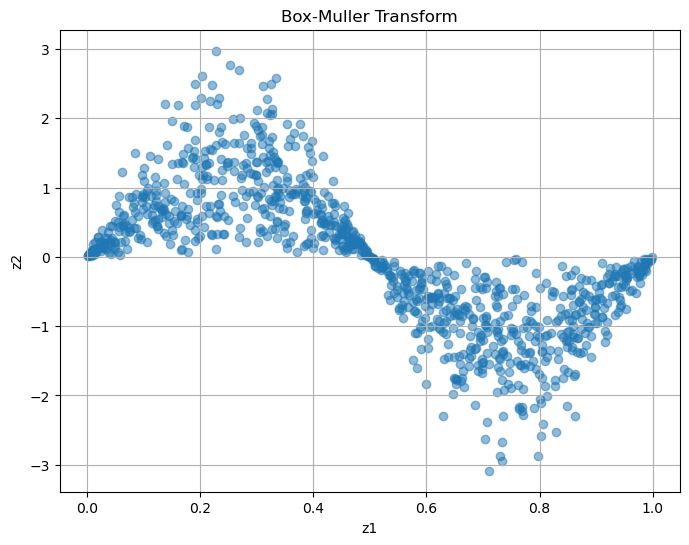

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_box_muller(num_samples=1000):
    # Generate two independent uniform random arrays x1 and x2
    x1 = np.random.random(num_samples)
    x2 = np.random.random(num_samples)
    
    # Compute z1 and z2 using the Box-Muller transformation
    z1 = np.sqrt(-2 * np.log(x1)) * np.cos(2 * np.pi * x2)
    z2 = np.sqrt(-2 * np.log(x1)) * np.sin(2 * np.pi * x2)
    
    # Plot the results
    plt.figure(figsize=(8,6))
    plt.scatter(x2, z2, alpha=0.5)
    plt.title("Box-Muller Transform")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.grid(True)
    plt.show()

# Call the function to display the plot
plot_box_muller()

(-0.8, 5.8, -0.25, 0.55)

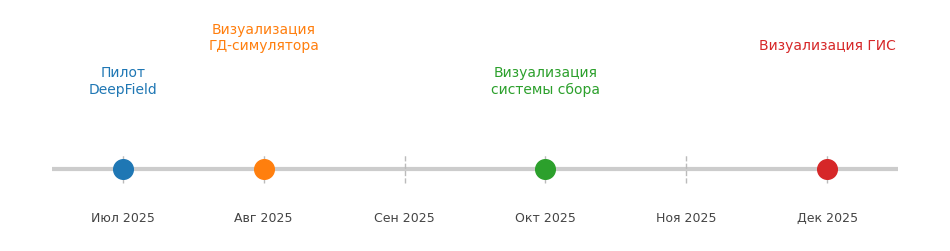

In [3]:
import matplotlib.pyplot as plt

# Months from July to December 2025
months = ["Июл 2025", "Авг 2025", "Сен 2025", "Окт 2025", "Ноя 2025", "Дек 2025"]
month_positions = list(range(len(months)))

# Milestones: (month_index, label, color)
milestones = [
    (0, "Пилот\nDeepField", "#1f77b4"),              # July
    (1, "Визуализация\nГД‑симулятора", "#ff7f0e"),    # August
    (3, "Визуализация\nсистемы сбора", "#2ca02c"),   # October
    (5, "Визуализация ГИС", "#d62728"),  # December
]

fig, ax = plt.subplots(figsize=(12, 3))

# Baseline
ax.hlines(0, -0.5, len(months) - 0.5, color="#cccccc", linewidth=3, zorder=0)

# Month ticks and labels
for idx, month in enumerate(months):
    ax.vlines(idx, -0.05, 0.05, color="#bbbbbb", linestyle="--", linewidth=1, zorder=0)
    ax.text(idx, -0.15, month, ha='center', va='top', fontsize=9, color="#444444")

# Plot milestones
label_heights = [0.25, 0.4, 0.25, 0.4]  # stagger labels to avoid overlap
for (idx, label, color), y_label in zip(milestones, label_heights):
    ax.scatter(idx, 0, s=200, color=color, zorder=5)
    ax.text(idx, y_label, label, ha='center', va='bottom', fontsize=10, color=color, wrap=True)

ax.set_ylim(-0.25, 0.55)
ax.axis('off')

# file_path = "/mnt/data/timeline_jul_dec.png"
# plt.savefig(file_path, bbox_inches='tight', dpi=300)
# file_path
